# Esperimenti di prova


Sono state eliminate le parti superflue di analisi iniziale del dataset e baseline descrittive. Restano solo gli esperimenti collegati a Exercise 2, Exercise 3.1 e Exercise 3.2, con gli output originali preservati nelle celle archiviate.

## Come leggere questo notebook

- Le prime celle usano la pipeline nuova e sono pensate per essere rieseguite.
- Le celle marcate come archivio provengono dal vecchio notebook e conservano gli output gia' stampati.
- Le celle storiche sono lasciate come prova dei tentativi fatti, non come codice da rilanciare automaticamente.

In [ ]:
from pathlib import Path
import sys

import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dla_lab1.config import experiment_config, load_config
from dla_lab1.experiments import batch_size_for, run_finetuning
from dla_lab1.evaluate import history_to_frame
from dla_lab1.models import build_classifier, count_parameters
from dla_lab1.paths import resolve_path

config = load_config(ROOT / "config" / "config.yaml")

# Default prudente: il notebook non rilancia training lunghi quando viene aperto.
RUN_TRAINING = False

print(f"Project root: {ROOT}")
print(f"Device disponibile: {'cuda' if torch.cuda.is_available() else 'cpu'}")

In [ ]:
selected_experiments = [
    "ex1_3_head_only_adam_ce",
    "ex3_1_layer4_unfrozen",
    "ex3_1_head_only_aggressive_aug",
    "ex3_1_layer4_aggressive_aug",
    "ex3_1_layer4_conservative_aug",
    "ex3_1_layer4_spatial_aug",
]

rows = []
for name in selected_experiments:
    exp = experiment_config(config, name)
    rows.append([
        name,
        exp["model"]["name"],
        exp["model"].get("unfreeze_layer4", False),
        exp["experiment"].get("augmentation", "none"),
        exp["training"]["optimizer"],
        exp["training"]["loss"],
        exp["training"]["learning_rate"],
        exp["training"]["epochs"],
        batch_size_for(config, exp["experiment"]["batch_size_key"]),
    ])

pd.DataFrame(rows, columns=[
    "Experiment",
    "Model",
    "Unfreeze layer4",
    "Augmentation",
    "Optimizer",
    "Loss",
    "Learning rate",
    "Epochs",
    "Batch size",
])

## Exercise 2 - Pipeline consolidation e screening iniziale

Questa sezione conserva le prove head-only fatte nel vecchio notebook cambiando optimizer e loss: CrossEntropy, WeightedCrossEntropy e FocalLoss con Adam, AdamW e SGD.

Nel codice nuovo la stessa logica e' stata consolidata in `run_finetuning`, `train_model`, `build_classifier`, `build_loss` e `config/config.yaml`.

In [ ]:
experiment_to_run = "ex1_3_head_only_adam_ce"

if RUN_TRAINING:
    result = run_finetuning(config, experiment_to_run, root=ROOT)
    history = history_to_frame(result["history"])
    display(history)
    print(f"Run salvata in: {result['artifacts']['output_dir']}")
else:
    print("Training non eseguito. Imposta RUN_TRAINING = True per rilanciare la run dalla pipeline nuova.")

### Archivio output storico - Exercise 2

In [30]:
# =========================================================================
# ESEGUIRE PRIMA DEGLI ESPERIMENTI (Split Robusto Anti-Leakage)
# =========================================================================
from torch.utils.data import DataLoader, Subset
import torch
import numpy as np

# 1. Split basato sui 'track' (30 immagini per ogni cartello fisico in GTSRB)
# Questo assicura che un cartello sia o tutto nel Training o tutto nel Validation.
num_samples = len(ds_train_raw)  # ← Usa dataset RAW
num_tracks = num_samples // 30
remaining = num_samples % 30

track_indices = np.arange(num_tracks)
np.random.seed(42)
np.random.shuffle(track_indices)

train_track_count = int(0.8 * num_tracks)
idx_train_tracks = track_indices[:train_track_count]
idx_val_tracks = track_indices[train_track_count:]

# Espandi a indici effettivi
train_indices = []
for t in idx_train_tracks:
    train_indices.extend(range(t * 30, (t + 1) * 30))

val_indices = []
for t in idx_val_tracks:
    val_indices.extend(range(t * 30, (t + 1) * 30))

# Aggiungi immagini rimanenti al training
if remaining > 0:
    for i in range(num_samples - remaining, num_samples):
        train_indices.append(i)

ds_train_real = Subset(ds_train, train_indices)
ds_val = Subset(ds_train, val_indices)

# 2. Creiamo i Dataloader
batch_size_base = 64 # Alziamo un po' il batch per stabilità
use_pin_memory = (device.type == 'cuda')
dl_train_real = DataLoader(ds_train_real, batch_size=batch_size_base, 
                          shuffle=True, pin_memory=use_pin_memory)
dl_val = DataLoader(ds_val, batch_size=batch_size_base, 
                   shuffle=False, pin_memory=use_pin_memory)

print(f"Split completato: {len(ds_train_real)} train, {len(ds_val)} validation samples.")
print("DataLoader pronti (Anti-Leakage attivo).")

# --- CALCOLO PESI DELLE CLASSI (Una sola volta) ---
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Subset
import numpy as np
print("Calcolo dei pesi bilanciati (operazione lenta, eseguita una volta)...")
# Ora calcola i pesi solo sul training
all_labels_train = [ds_train[i][1] for i in train_indices]  # Solo train
class_weights_global = compute_class_weight(
    'balanced', 
    classes=np.unique(all_labels_train), 
    y=all_labels_train
)
print("Pesi calcolati e pronti.")


Split completato: 21300 train, 5340 validation samples.
DataLoader pronti (Anti-Leakage attivo).
Calcolo dei pesi bilanciati (operazione lenta, eseguita una volta)...
Pesi calcolati e pronti.


In [31]:
from torchvision.models import get_model
from engine import train_and_evaluate
import torch.nn as nn

# restituisce un modello nuovo e insipendente, in modo da garantire riproducibilità e correttezza degli esperimenti

def get_fresh_model():
    m = get_model('resnet18', weights='DEFAULT')
    # 1. Sostituisci PRIMA fc
    m.fc = nn.Linear(512, 43)
    # 2. POI congela solo il backbone
    for name, param in m.named_parameters():
        if not name.startswith('fc'):
            param.requires_grad = False
    return m.to(device)

print("Funzione get_fresh_model definita correttamente.")

Funzione get_fresh_model definita correttamente.


ADAM CrossEntrophy

In [32]:
config_run_1 = {
    "experiment_name": "Adam_CrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "CrossEntropy",
    "batch_size": 64
}

modello_addestrato_1 = train_and_evaluate(
    config=config_run_1,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global
)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


c:\Users\checc\OneDrive\Desktop\DLA_1\engine.py:170: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None


⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [TRAIN]:   0%|          | 0/333 [00:00<?, ?it/s]c:\Users\checc\OneDrive\Desktop\DLA_1\engine.py:330: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:06<00:00, 13.20it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 1.7113 | Train Acc: 0.5243 | Val Loss: 1.8216 | Val Acc: 0.4897
  ✓ Nuovo best model salvato (val_acc: 0.4897)


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 0.5778 | Train Acc: 0.8300 | Val Loss: 1.7586 | Val Acc: 0.5223
  ⚠️  Nessun miglioramento (1/5)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:10<00:00,  7.87it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 0.5748 | Train Acc: 0.8286 | Val Loss: 1.7678 | Val Acc: 0.5187
  ⚠️  Nessun miglioramento (2/5)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▅▆▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▃▅▅▆▇▇█▇▆
Validation/Loss,▆▂▃█▄▂▁▂▁▂
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.82859
Train/Loss,0.57481
Validation/Accuracy,0.51873
Validation/Loss,1.76783


✓ Addestramento completato!


AdamW CrossEntrophy (MIGLIORE)

In [33]:
#--- ESPERIMENTO 2: AdamW + CrossEntropy ---
config_run_2 = {
    "experiment_name": "AdamW_CrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 64
}

modello_addestrato_2 = train_and_evaluate(
    config=config_run_2,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global
)

⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:06<00:00, 13.97it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 1.7110 | Train Acc: 0.5253 | Val Loss: 1.8116 | Val Acc: 0.4751
  ✓ Nuovo best model salvato (val_acc: 0.4751)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:07<00:00, 11.11it/s]


Epoca 2/10 | LR: 0.001000 | Train Loss: 0.9514 | Train Acc: 0.7167 | Val Loss: 1.7860 | Val Acc: 0.4987
  ✓ Nuovo best model salvato (val_acc: 0.4987)


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 0.5817 | Train Acc: 0.8278 | Val Loss: 1.7537 | Val Acc: 0.5191
  ⚠️  Nessun miglioramento (4/5)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:08<00:00,  9.99it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 0.5829 | Train Acc: 0.8282 | Val Loss: 1.7621 | Val Acc: 0.5236
  ⚠️  Nessun miglioramento (5/5)
Early stopping attivato all'epoca 10
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▅▆▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▄▆▆████▇█
Validation/Loss,█▆▁█▃▃▃▁▂▃
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.82822
Train/Loss,0.58294
Validation/Accuracy,0.5236
Validation/Loss,1.76208


✓ Addestramento completato!


SGD CrossEntrophy

In [34]:
# --- ESPERIMENTO 3: SGD + CrossEntropy ---
config_run_3 = {
    "experiment_name": "SGD_CrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "SGD",
    "loss": "CrossEntropy",
    "batch_size": 64,
    "momentum": 0.9  # Parametro specifico per SGD
}

modello_addestrato_3 = train_and_evaluate(
    config=config_run_3,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global
)

⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:08<00:00, 10.48it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 3.2642 | Train Acc: 0.1708 | Val Loss: 2.8576 | Val Acc: 0.2805
  ✓ Nuovo best model salvato (val_acc: 0.2805)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:08<00:00,  9.37it/s]


Epoca 2/10 | LR: 0.001000 | Train Loss: 2.4600 | Train Acc: 0.3705 | Val Loss: 2.4485 | Val Acc: 0.3788
  ✓ Nuovo best model salvato (val_acc: 0.3788)


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 1.6456 | Train Acc: 0.5678 | Val Loss: 2.0841 | Val Acc: 0.4463
  ✓ Nuovo best model salvato (val_acc: 0.4463)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 14.81it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 1.6467 | Train Acc: 0.5650 | Val Loss: 2.0863 | Val Acc: 0.4434
  ⚠️  Nessun miglioramento (1/5)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▅▆▇██████
Train/Loss,█▅▃▂▁▁▁▁▁▁
Validation/Accuracy,▁▅▇███████
Validation/Loss,█▄▃▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.56498
Train/Loss,1.64671
Validation/Accuracy,0.44345
Validation/Loss,2.08627


✓ Addestramento completato!


SGD WeightedCrossEntropy

In [35]:
# --- ESPERIMENTO 4: SGD + WeightedCrossEntropy ---
config_run_4 = {
    "experiment_name": "SGD_WeightedCrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "SGD",
    "loss": "WeightedCrossEntropy",
    "batch_size": 64,
    "momentum": 0.9
}

modello_addestrato_4 = train_and_evaluate(
    config=config_run_4,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per WeightedCE
)

⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 14.99it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 3.6361 | Train Acc: 0.0726 | Val Loss: 3.3605 | Val Acc: 0.1199
  ✓ Nuovo best model salvato (val_acc: 0.1199)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 16.35it/s]


Epoca 2/10 | LR: 0.001000 | Train Loss: 2.8428 | Train Acc: 0.2446 | Val Loss: 2.9050 | Val Acc: 0.2481
  ✓ Nuovo best model salvato (val_acc: 0.2481)


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 1.8305 | Train Acc: 0.5012 | Val Loss: 2.4247 | Val Acc: 0.3541
  ⚠️  Nessun miglioramento (4/5)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 14.97it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 1.8294 | Train Acc: 0.4974 | Val Loss: 2.4157 | Val Acc: 0.3552
  ✓ Nuovo best model salvato (val_acc: 0.3552)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▄▆▇██████
Train/Loss,█▅▃▂▁▁▁▁▁▁
Validation/Accuracy,▁▅▇███████
Validation/Loss,█▅▃▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.49737
Train/Loss,1.82943
Validation/Accuracy,0.35524
Validation/Loss,2.41572


✓ Addestramento completato!


Adam_WeightedCrossEntropy

In [36]:
# --- ESPERIMENTO 5: Adam + WeightedCrossEntropy ---
config_run_5 = {
    "experiment_name": "Adam_WeightedCrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "WeightedCrossEntropy",
    "batch_size": 64,
}

modello_addestrato_5 = train_and_evaluate(
    config=config_run_5,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per WeightedCE
)

⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:08<00:00, 10.42it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 1.8193 | Train Acc: 0.4959 | Val Loss: 1.9327 | Val Acc: 0.4640
  ✓ Nuovo best model salvato (val_acc: 0.4640)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:09<00:00,  9.13it/s]


Epoca 2/10 | LR: 0.001000 | Train Loss: 0.9229 | Train Acc: 0.6940 | Val Loss: 1.9671 | Val Acc: 0.4908
  ✓ Nuovo best model salvato (val_acc: 0.4908)


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 0.4826 | Train Acc: 0.8115 | Val Loss: 2.0170 | Val Acc: 0.5096
  ⚠️  Nessun miglioramento (2/5)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 14.60it/s]

Epoca 10/10 | LR: 0.000010 | Train Loss: 0.4837 | Train Acc: 0.8078 | Val Loss: 2.0138 | Val Acc: 0.5125
  ⚠️  Nessun miglioramento (3/5)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▅▆▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▅▄▅▇▇█▇▇█
Validation/Loss,▁▃██▄▄▃▅▅▅
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.80779
Train/Loss,0.48372
Validation/Accuracy,0.51255
Validation/Loss,2.01381


✓ Addestramento completato!


AdamW_WeightedCrossEntropy

In [37]:
# --- ESPERIMENTO 6: AdamW + WeightedCrossEntropy ---
config_run_6 = {
    "experiment_name": "AdamW_WeightedCrossEntropy",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "AdamW",
    "loss": "WeightedCrossEntropy",
    "batch_size": 64,
}

modello_addestrato_6 = train_and_evaluate(
    config=config_run_6,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per WeightedCE
)

⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 16.07it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 1.8182 | Train Acc: 0.4985 | Val Loss: 2.0134 | Val Acc: 0.4738
  ✓ Nuovo best model salvato (val_acc: 0.4738)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 15.19it/s]


Epoca 2/10 | LR: 0.001000 | Train Loss: 0.9312 | Train Acc: 0.6935 | Val Loss: 1.9571 | Val Acc: 0.4809
  ✓ Nuovo best model salvato (val_acc: 0.4809)


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 0.4825 | Train Acc: 0.8130 | Val Loss: 2.0270 | Val Acc: 0.5094
  ✓ Nuovo best model salvato (val_acc: 0.5094)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 14.76it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 0.4891 | Train Acc: 0.8097 | Val Loss: 1.9923 | Val Acc: 0.5135
  ✓ Nuovo best model salvato (val_acc: 0.5135)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▅▆▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▂▃▆▇▇▇▇▇█
Validation/Loss,▄▁█▅▄▅▄▅▅▃
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.80972
Train/Loss,0.48914
Validation/Accuracy,0.51348
Validation/Loss,1.99234


✓ Addestramento completato!


In [38]:
%load_ext autoreload
%autoreload 2
from engine import train_and_evaluate
from engine import FocalLoss # per forzare anche il ricaricamento di questa classe

SGD_FocalLoss_Pesi

In [39]:
# --- ESPERIMENTO 7: SGD + FocalLoss ---
config_run_7 = {
    "experiment_name": "SGD_FocalLoss",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "SGD",
    "loss": "FocalLoss",
    "gamma_focal": 2.0,  # Parametro Focal Loss
    "alpha_focal": 1.0,
    "batch_size": 64,
    "momentum": 0.9
}

modello_addestrato_7 = train_and_evaluate(
    config=config_run_7,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per FocalLoss
)

c:\Users\checc\OneDrive\Desktop\DLA_1\engine.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weights_tensor = torch.tensor(weights, dtype=torch.float32)


⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 15.89it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 3.2075 | Train Acc: 0.0767 | Val Loss: 2.9264 | Val Acc: 0.1403
  ✓ Nuovo best model salvato (val_acc: 0.1403)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 14.29it/s]


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 1.3515 | Train Acc: 0.4757 | Val Loss: 2.0490 | Val Acc: 0.3294
  ✓ Nuovo best model salvato (val_acc: 0.3294)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:06<00:00, 12.57it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 1.3506 | Train Acc: 0.4777 | Val Loss: 2.0263 | Val Acc: 0.3322
  ✓ Nuovo best model salvato (val_acc: 0.3322)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▄▆▇██████
Train/Loss,█▅▃▂▁▁▁▁▁▁
Validation/Accuracy,▁▄▆███████
Validation/Loss,█▄▃▂▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.47765
Train/Loss,1.35059
Validation/Accuracy,0.33221
Validation/Loss,2.02626


✓ Addestramento completato!


AdamW_FocalLoss_Pesi

In [40]:

# --- ESPERIMENTO 8: Adam + FocalLoss ---
config_run_8 = {
    "experiment_name": "Adam_FocalLoss",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "FocalLoss",
    "gamma_focal": 2.0,
    "alpha_focal": 1.0,
    "batch_size": 64
}

modello_addestrato_8 = train_and_evaluate(
    config=config_run_8,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per FocalLoss
)

⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:09<00:00,  8.62it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 1.4166 | Train Acc: 0.4795 | Val Loss: 1.6340 | Val Acc: 0.4373
  ✓ Nuovo best model salvato (val_acc: 0.4373)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:10<00:00,  7.84it/s]


Epoca 2/10 | LR: 0.001000 | Train Loss: 0.6013 | Train Acc: 0.6656 | Val Loss: 1.6020 | Val Acc: 0.4800
  ✓ Nuovo best model salvato (val_acc: 0.4800)


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 0.2446 | Train Acc: 0.7888 | Val Loss: 1.7307 | Val Acc: 0.4852
  ⚠️  Nessun miglioramento (3/5)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 15.30it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 0.2378 | Train Acc: 0.7935 | Val Loss: 1.7157 | Val Acc: 0.4758
  ⚠️  Nessun miglioramento (4/5)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▅▆▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▇▆▄▆█▇██▇
Validation/Loss,▂▁███▇▇▆▆▅
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.79352
Train/Loss,0.23784
Validation/Accuracy,0.47584
Validation/Loss,1.71573


✓ Addestramento completato!


In [ ]:
# --- ESPERIMENTO 9: AdamW + FocalLoss ---
config_run_9 = {
    "experiment_name": "AdamW_FocalLoss",
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "AdamW",
    "loss": "FocalLoss",
    "gamma_focal": 2.0,
    "alpha_focal": 1.0,
    "batch_size": 64
}

modello_addestrato_9 = train_and_evaluate(
    config=config_run_9,
    model=get_fresh_model(),  # Modello nuovo da zero
    train_loader=dl_train_real,
    val_loader=dl_val,
    device=device,
    class_weights=class_weights_global  # Necessari per FocalLoss
)

Learning_Rate,█████▃▃▃▃▃▁▁
Train/Accuracy,▁▇▇█████████
Train/Loss,█▂▂▁▁▁▁▁▁▁▁▁
Validation/Accuracy,▁▃▅▆▆███▇███
Validation/Loss,█▆▃▃▅▁▂▂▂▂▂▂
epoch,▁▂▂▃▄▄▅▅▆▇▇█
Learning_Rate,0.00013
Train/Accuracy,1
Train/Loss,0.00025
Validation/Accuracy,0.82678
Validation/Loss,0.74655


⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 84/84 [00:06<00:00, 12.96it/s]


Epoca 1/10 | LR: 0.001000 | Train Loss: 1.4220 | Train Acc: 0.4851 | Val Loss: 1.7663 | Val Acc: 0.4414
  ✓ Nuovo best model salvato (val_acc: 0.4414)


Epoca 2/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 15.46it/s]


...

Epoca 9/10 | LR: 0.000010 | Train Loss: 0.2371 | Train Acc: 0.7947 | Val Loss: 1.6960 | Val Acc: 0.4882
  ⚠️  Nessun miglioramento (1/5)


Epoca 10/10 [VAL]: 100%|██████████| 84/84 [00:05<00:00, 15.90it/s]


Epoca 10/10 | LR: 0.000010 | Train Loss: 0.2345 | Train Acc: 0.7932 | Val Loss: 1.7201 | Val Acc: 0.4925
  ✓ Nuovo best model salvato (val_acc: 0.4925)
✓ Best model caricato da best_model.pt


Learning_Rate,████▂▂▂▂▁▁
Train/Accuracy,▁▅▆▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▃▄▄▇▇▇█▇█
Validation/Loss,▅█▃▆▂▂▁▂▁▂
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,1e-05
Train/Accuracy,0.79324
Train/Loss,0.23453
Validation/Accuracy,0.49251
Validation/Loss,1.72009


✓ Addestramento completato!


In [42]:
# =========================================================================
# RECAP ESERCIZIO 2 – PIPELINE CONSOLIDATION & FINE-TUNING
# =========================================================================
# In questo capitolo abbiamo consolidato la pipeline sperimentale:
# - Suddivisione robusta train/validation basata sui track dei cartelli (anti-leakage)
# - Calcolo dei pesi di classe per gestire il dataset sbilanciato
# - Funzione modulare `train_and_evaluate` per addestramento e validazione con logging e salvataggio del miglior modello
# - Esperimenti multipli con diversi ottimizzatori (Adam, AdamW, SGD) e loss (CrossEntropy, Weighted CrossEntropy, Focal Loss)
# - Fine-tuning selettivo del backbone ResNet-18: congelato tranne lo strato finale `fc`
# - Mixed Precision Training abilitato per velocizzare il training
# 
# Miglior modello finale: AdamW + CrossEntropy
# - Train Accuracy: ~82.5%, Validation Accuracy: ~52.5%
# - Il modello mostra buon apprendimento sui pattern dei cartelli, ma la performance sulle classi rare rimane limitata a causa dello sbilanciamento
# 
# La pipeline è ora riproducibile, modulare e pronta per futuri esperimenti o tuning aggiuntivi.

## Exercise 3.1 - Miglioramento del fine-tuning

Qui sono archiviate le prove di miglioramento successive alla baseline: sblocco di `layer4`, augmentation aggressiva, augmentation conservativa, variante solo spaziale e valutazione finale.

La versione nuova preferisce configurazioni riproducibili in `config/config.yaml`, in particolare `ex3_1_layer4_conservative_aug` e `ex3_1_layer4_spatial_aug`.

In [ ]:
SELECTED_EXPERIMENT = "ex3_1_layer4_conservative_aug"
selected_cfg = experiment_config(config, SELECTED_EXPERIMENT)

model = build_classifier(
    model_name=selected_cfg["model"]["name"],
    num_classes=int(config["project"]["num_classes"]),
    weights=selected_cfg["model"].get("weights", "DEFAULT"),
    freeze_backbone=bool(selected_cfg["model"].get("freeze_backbone", True)),
    unfreeze_layer4=bool(selected_cfg["model"].get("unfreeze_layer4", False)),
)

parameter_summary = pd.DataFrame([count_parameters(model)])
parameter_summary["trainable_ratio"] = parameter_summary["trainable"] / parameter_summary["total"]
parameter_summary

In [ ]:
if RUN_TRAINING:
    result = run_finetuning(config, SELECTED_EXPERIMENT, root=ROOT)
    history = history_to_frame(result["history"])
    display(history)
    print(f"Run salvata in: {result['artifacts']['output_dir']}")
else:
    print("Training non eseguito. Imposta RUN_TRAINING = True per rilanciare Exercise 3.1 dalla pipeline nuova.")

### Archivio output storico - Exercise 3.1

In [50]:
# =========================================================================
# DEBUG: Verifica quale ResNet stai usando
# =========================================================================
from torchvision.models import get_model
import torch.nn as nn

# Carica un modello pulito
model_debug = get_model('resnet18', weights='DEFAULT')

# Stampa l'architettura
print("=" * 60)
print("ARCHITETTURA MODELLO")
print("=" * 60)
print(model_debug)
print()

# Conta parametri per layer
print("=" * 60)
print("PARAMETRI PER LAYER")
print("=" * 60)
for name, module in model_debug.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"{name:<15} {params:>15,} parametri")

total = sum(p.numel() for p in model_debug.parameters())
print("=" * 60)
print(f"{'TOTALE':<15} {total:>15,} parametri")
print("=" * 60)
print()

# Verifica la dimensione del FC layer
print(f"FC layer input features: {model_debug.fc.in_features}")
print(f"FC layer output features: {model_debug.fc.out_features}")
print()

del model_debug

ARCHITETTURA MODELLO
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): 

In [45]:
# %%
# =========================================================================
# Exercise 3.1: Selective Layer Training
# =========================================================================

def get_model_layer4_unfrozen():
    """
    ResNet-18 con layer4 e fc trainabili.
    
    Strategia conservativa per migliorare le performance:
    - Backbone (layer1, layer2, layer3): Congelato (pesi ImageNet)
    - Layer4: Trainabile (~8.4M parametri)
    - FC: Trainabile (~22K parametri)
    
    Totale parametri trainabili: ~8.4M (vs ~22K del baseline)
    Percentuale trainabile: ~75%
    """
    from torchvision.models import resnet18
    m = resnet18(weights='IMAGENET1K_V1')
    
    # 1. Sostituisci il classificatore
    m.fc = nn.Linear(512, 43)
    
    # 2. PRIMA congela TUTTO
    for param in m.parameters():
        param.requires_grad = False
    
    # 3. POI scongela SOLO layer4 e fc
    for name, param in m.named_parameters():
        if name.startswith('layer4') or name.startswith('fc'):
            param.requires_grad = True
    
    return m.to(device)

# =========================================================================
# VERIFICA
# =========================================================================
model_test = get_model_layer4_unfrozen()

trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_test.parameters())

print("=" * 60)
print("VERIFICA LAYER TRAINABILI")
print("=" * 60)
print(f"Parametri trainabili: {trainable_params:,}")
print(f"Parametri totali: {total_params:,}")
print(f"Percentuale: {100*trainable_params/total_params:.1f}%")
print()

# Validazione corretta
if 8_300_000 <= trainable_params <= 8_500_000:
    print("✅ CORRETTO! Layer4 + FC sono trainabili (~8.4M parametri).")
    print("   Questo è il valore atteso per ResNet-18 con layer4 scongelato.")
else:
    print(f"⚠️  WARNING: Valore inaspettato ({trainable_params:,} parametri).")

print("=" * 60)
del model_test
print("✓ Funzione definita correttamente.")

VERIFICA LAYER TRAINABILI
Parametri trainabili: 8,415,787
Parametri totali: 11,198,571
Percentuale: 75.2%

✅ CORRETTO! Layer4 + FC sono trainabili (~8.4M parametri).
   Questo è il valore atteso per ResNet-18 con layer4 scongelato.
✓ Funzione definita correttamente.


In [46]:
# Abilita Mixed Precision (solo se hai GPU NVIDIA con Tensor Cores)
import torch

# Verifica se Mixed Precision è disponibile
if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 7:
    print("✅ Mixed Precision disponibile (GPU supporta Tensor Cores)")
    use_amp = True
else:
    print("⚠️  Mixed Precision non disponibile o GPU non supporta Tensor Cores")
    use_amp = False

✅ Mixed Precision disponibile (GPU supporta Tensor Cores)


AdamW_CrossEntropy + Layer4 Unfrozen

In [51]:
# =========================================================================
# ESPERIMENTO 9: Layer4 Unfrozen (VERSIONE VELOCE)
# =========================================================================

# Dataloader ottimizzati (batch più grande)
batch_size_fast = 128

dl_train_fast = DataLoader(
    ds_train_real, 
    batch_size=batch_size_fast, 
    shuffle=True, 
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

dl_val_fast = DataLoader(
    ds_val, 
    batch_size=batch_size_fast,
    shuffle=False, 
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

# Configurazione
config_run_9 = {
    "experiment_name": "AdamW_CE_Layer4Unfrozen",
    "epochs": 15,
    "learning_rate": 0.0005,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.1,
    "step_size": 5,
    "gamma_lr": 0.5,
    "patience": 6
}

print("⚡ CONFIGURAZIONE VELOCE")
print("=" * 60)
print(f"Batch size: 128 (raddoppiato)")
print(f"Iterazioni per epoca: {len(dl_train_fast)}")
print(f"Tempo stimato totale: 15-20 minuti")
print("=" * 60)
print()

modello_addestrato_9 = train_and_evaluate(
    config=config_run_9,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_fast,
    val_loader=dl_val_fast,
    device=device,
    class_weights=class_weights_global
)

⚡ CONFIGURAZIONE VELOCE
Batch size: 128 (raddoppiato)
Iterazioni per epoca: 167
Tempo stimato totale: 15-20 minuti



⚡ Mixed Precision Training ABILITATO


Epoca 1/15 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  8.24it/s]


Epoca 1/15 | LR: 0.000500 | Train Loss: 0.4730 | Train Acc: 0.8652 | Val Loss: 0.9455 | Val Acc: 0.7388
  ✓ Nuovo best model salvato (val_acc: 0.7388)


Epoca 2/15 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.51it/s]


...

Epoca 14/15 | LR: 0.000125 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.8544 | Val Acc: 0.8088
  ✓ Nuovo best model salvato (val_acc: 0.8088)


Epoca 15/15 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.55it/s]

Epoca 15/15 | LR: 0.000125 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.8886 | Val Acc: 0.8045
  ⚠️  Nessun miglioramento (1/6)
✓ Best model caricato da best_model.pt


Learning_Rate,█████▃▃▃▃▃▁▁▁▁▁
Train/Accuracy,▁▇▇████████████
Train/Loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁
Validation/Accuracy,▁▁▄▅▇▇█▇▆▆▇▇███
Validation/Loss,▅█▃▅▂▂▁▃▆▅▂▃▂▁▃
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
Learning_Rate,0.00013
Train/Accuracy,1
Train/Loss,0.00017
Validation/Accuracy,0.80449
Validation/Loss,0.88859


✓ Addestramento completato!


In [52]:
# %%
# =========================================================================
# Exercise 3.1: Data Augmentation Transform
# =========================================================================

# Transform SENZA augmentation (baseline attuale)
transform_baseline = T.Compose([
    T.Resize(70),
    T.CenterCrop((64, 64)),  # Deterministico
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Transform CON augmentation (nuovo per training)
transform_augmented = T.Compose([
    T.Resize(70),
    T.RandomCrop((64, 64)),           # ← Crop casuale invece di centrato
    T.RandomHorizontalFlip(p=0.3),    # ← Flip orizzontale (30% probabilità)
    T.ColorJitter(                     # ← Variazioni di colore
        brightness=0.2,                # ± 20% luminosità
        contrast=0.2,                  # ± 20% contrasto
        saturation=0.15,               # ± 15% saturazione
        hue=0.05                       # ± 5% tonalità
    ),
    T.RandomRotation(degrees=10),     # ← Rotazione ±10° (moderata)
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Transform per VALIDATION (sempre senza augmentation!)
transform_val = T.Compose([
    T.Resize(70),
    T.CenterCrop((64, 64)),  # ← CenterCrop per validation
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

print("✓ Transform definiti:")
print("  - transform_baseline: Nessuna augmentation (CenterCrop)")
print("  - transform_augmented: RandomCrop + Flip + ColorJitter + Rotation")
print("  - transform_val: Solo CenterCrop (per validation)")

✓ Transform definiti:
  - transform_baseline: Nessuna augmentation (CenterCrop)
  - transform_augmented: RandomCrop + Flip + ColorJitter + Rotation
  - transform_val: Solo CenterCrop (per validation)


In [53]:
# %%
# =========================================================================
# Dataset e DataLoader con Data Augmentation
# =========================================================================

# IMPORTANTE: Ricarichiamo il dataset RAW dal disco
ds_train_raw_aug = GTSRB('data/', split='train', transform=None, download=True)

# 1. Dataset TRAINING con augmentation
ds_train_aug = GTSRB('data/', split='train', transform=transform_augmented, download=True)

# 2. Dataset VALIDATION senza augmentation (IMPORTANTE!)
ds_val_no_aug = GTSRB('data/', split='train', transform=transform_val, download=True)

# 3. Creiamo i Subset usando gli STESSI indici di prima (anti-leakage)
# NOTA: Usiamo train_indices e val_indices già calcolati prima!
ds_train_real_aug = Subset(ds_train_aug, train_indices)
ds_val_real_no_aug = Subset(ds_val_no_aug, val_indices)

# 4. Dataloader ottimizzati
batch_size_aug = 128

dl_train_aug = DataLoader(
    ds_train_real_aug,
    batch_size=batch_size_aug,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

dl_val_no_aug = DataLoader(
    ds_val_real_no_aug,
    batch_size=batch_size_aug,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

print("=" * 60)
print("DATASET CON DATA AUGMENTATION")
print("=" * 60)
print(f"Training samples: {len(ds_train_real_aug)}")
print(f"Validation samples: {len(ds_val_real_no_aug)}")
print(f"Training augmentation: RandomCrop, Flip, ColorJitter, Rotation")
print(f"Validation augmentation: Nessuna (solo CenterCrop)")
print("=" * 60)
print()
print("✓ Dataset pronti per l'esperimento con Data Augmentation")

DATASET CON DATA AUGMENTATION
Training samples: 21300
Validation samples: 5340
Training augmentation: RandomCrop, Flip, ColorJitter, Rotation
Validation augmentation: Nessuna (solo CenterCrop)

✓ Dataset pronti per l'esperimento con Data Augmentation


In [54]:
# %%
# =========================================================================
# ESPERIMENTO 10: Baseline (Solo FC) + Data Augmentation
# =========================================================================

config_run_10 = {
    "experiment_name": "Ex3.1_AdamW_CE_OnlyAugmentation",
    "epochs": 15,
    "learning_rate": 0.001,  # ← Stesso LR del baseline originale
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.01,
    "step_size": 5,
    "gamma_lr": 0.5,
    "patience": 6
}

print("🔬 ESPERIMENTO: Solo Data Augmentation (Baseline Model)")
print("=" * 60)
print("Modello: ResNet-18 (Solo FC trainabile, ~22K parametri)")
print("Augmentation: RandomCrop + Flip + ColorJitter + Rotation")
print()
print("📊 CONFRONTO ATTESO:")
print("  Baseline (no aug):     53.28% val acc")
print("  Layer4 unfrozen:       82.47% val acc")
print("  Solo Augmentation:     ?? (target: 58-62%)")
print("=" * 60)
print()

modello_addestrato_10 = train_and_evaluate(
    config=config_run_10,
    model=get_fresh_model(),  # ← Usa il modello baseline (solo FC trainabile)
    train_loader=dl_train_aug,      # ← Training con augmentation
    val_loader=dl_val_no_aug,       # ← Validation SENZA augmentation
    device=device,
    class_weights=class_weights_global
)

🔬 ESPERIMENTO: Solo Data Augmentation (Baseline Model)
Modello: ResNet-18 (Solo FC trainabile, ~22K parametri)
Augmentation: RandomCrop + Flip + ColorJitter + Rotation

📊 CONFRONTO ATTESO:
  Baseline (no aug):     53.28% val acc
  Layer4 unfrozen:       82.47% val acc
  Solo Augmentation:     ?? (target: 58-62%)



⚡ Mixed Precision Training ABILITATO


Epoca 1/15 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.69it/s]


Epoca 1/15 | LR: 0.001000 | Train Loss: 2.2570 | Train Acc: 0.3750 | Val Loss: 1.9958 | Val Acc: 0.4457
  ✓ Nuovo best model salvato (val_acc: 0.4457)


Epoca 2/15 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  8.01it/s]


...

Epoca 14/15 | LR: 0.000250 | Train Loss: 1.0904 | Train Acc: 0.6556 | Val Loss: 1.6479 | Val Acc: 0.5135
  ✓ Nuovo best model salvato (val_acc: 0.5135)


Epoca 15/15 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  7.38it/s]

Epoca 15/15 | LR: 0.000250 | Train Loss: 1.0857 | Train Acc: 0.6598 | Val Loss: 1.6649 | Val Acc: 0.5054
  ⚠️  Nessun miglioramento (1/6)
✓ Best model caricato da best_model.pt


Learning_Rate,█████▃▃▃▃▃▁▁▁▁▁
Train/Accuracy,▁▅▆▇▇▇█▇███████
Train/Loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁
Validation/Accuracy,▁▂▅▆▅▅▆▆▆▆▇▇▇█▇
Validation/Loss,█▅▃▃▃▃▂▂▂▂▂▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
Learning_Rate,0.00025
Train/Accuracy,0.65977
Train/Loss,1.08573
Validation/Accuracy,0.50543
Validation/Loss,1.66492


✓ Addestramento completato!


In [55]:
# =========================================================================
# ESPERIMENTO 11: Layer4 Unfrozen + Data Augmentation
# =========================================================================

config_run_11 = {
    "experiment_name": "Ex3.1_AdamW_CE_Layer4_Plus_Aug",
    "epochs": 15,
    "learning_rate": 0.0005,  # ← LR più basso (come Esperimento 9)
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.02,  # ← Regolarizzazione più forte
    "step_size": 5,
    "gamma_lr": 0.5,
    "patience": 6
}

print("🚀 ESPERIMENTO FINALE: Layer4 Unfrozen + Data Augmentation")
print("=" * 60)
print("Modello: ResNet-18 (Layer4 + FC trainabili, ~8.4M parametri)")
print("Augmentation: RandomCrop + Flip + ColorJitter + Rotation")
print()
print("📊 CONFRONTO FINALE ATTESO:")
print("  Baseline (no aug):            53.28% val acc")
print("  Solo Augmentation:            ?? (Esp. 10)")
print("  Solo Layer4 unfrozen:         82.47% val acc")
print("  Layer4 + Augmentation:        ?? (target: 85-88%)")
print("=" * 60)
print()

modello_addestrato_11 = train_and_evaluate(
    config=config_run_11,
    model=get_model_layer4_unfrozen(),  # ← Modello con Layer4 unfrozen
    train_loader=dl_train_aug,          # ← Training con augmentation
    val_loader=dl_val_no_aug,           # ← Validation SENZA augmentation
    device=device,
    class_weights=class_weights_global
)

🚀 ESPERIMENTO FINALE: Layer4 Unfrozen + Data Augmentation
Modello: ResNet-18 (Layer4 + FC trainabili, ~8.4M parametri)
Augmentation: RandomCrop + Flip + ColorJitter + Rotation

📊 CONFRONTO FINALE ATTESO:
  Baseline (no aug):            53.28% val acc
  Solo Augmentation:            ?? (Esp. 10)
  Solo Layer4 unfrozen:         82.47% val acc
  Layer4 + Augmentation:        ?? (target: 85-88%)



⚡ Mixed Precision Training ABILITATO


Epoca 1/15 [VAL]: 100%|██████████| 42/42 [00:06<00:00,  6.63it/s]


Epoca 1/15 | LR: 0.000500 | Train Loss: 0.8484 | Train Acc: 0.7344 | Val Loss: 0.9401 | Val Acc: 0.7054
  ✓ Nuovo best model salvato (val_acc: 0.7054)


Epoca 2/15 [VAL]: 100%|██████████| 42/42 [00:06<00:00,  6.95it/s]


...

Epoca 14/15 | LR: 0.000125 | Train Loss: 0.0251 | Train Acc: 0.9921 | Val Loss: 0.9061 | Val Acc: 0.7959
  ⚠️  Nessun miglioramento (3/6)


Epoca 15/15 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  8.15it/s]


Epoca 15/15 | LR: 0.000125 | Train Loss: 0.0242 | Train Acc: 0.9918 | Val Loss: 0.9500 | Val Acc: 0.7961
  ⚠️  Nessun miglioramento (4/6)
✓ Best model caricato da best_model.pt


Learning_Rate,█████▃▃▃▃▃▁▁▁▁▁
Train/Accuracy,▁▅▆▇▇▇█████████
Train/Loss,█▃▃▂▂▁▁▁▁▁▁▁▁▁▁
Validation/Accuracy,▁▄▄▄▆▇▆▆▇▆█▇███
Validation/Loss,▆▃▄▇▄▃▅▆▁▆▃█▅▅▇
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
Learning_Rate,0.00013
Train/Accuracy,0.99178
Train/Loss,0.0242
Validation/Accuracy,0.79607
Validation/Loss,0.95001


✓ Addestramento completato!


In [56]:
# %%
# =========================================================================
# ESPERIMENTO 12: Layer4 + Augmentation Conservativa
# =========================================================================

# Transform conservativo (solo variazioni minime)
transform_aug_conservative = T.Compose([
    T.Resize(70),
    T.RandomCrop((64, 64)),
    T.ColorJitter(brightness=0.1, contrast=0.1),  # ← MOLTO ridotto
    T.RandomRotation(degrees=3),                   # ← MOLTO ridotto
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Ricrea dataset
ds_train_conservative = GTSRB('data/', split='train', transform=transform_aug_conservative)
ds_train_real_conservative = Subset(ds_train_conservative, train_indices)

dl_train_conservative = DataLoader(
    ds_train_real_conservative,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

config_run_12 = {
    "experiment_name": "Ex3.1_Layer4_AugConservative",
    "epochs": 10,  # Meno epoche (solo per test)
    "learning_rate": 0.0005,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.02,
    "step_size": 4,
    "gamma_lr": 0.5,
    "patience": 5
}

print("🧪 TEST: Augmentation Conservativa")
print("Target: >82% (battere solo Layer4)")
print()

modello_addestrato_12 = train_and_evaluate(
    config=config_run_12,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_conservative,
    val_loader=dl_val_no_aug,
    device=device,
    class_weights=class_weights_global
)

🧪 TEST: Augmentation Conservativa
Target: >82% (battere solo Layer4)



⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.65it/s]


Epoca 1/10 | LR: 0.000500 | Train Loss: 0.6214 | Train Acc: 0.8131 | Val Loss: 0.8668 | Val Acc: 0.7410
  ✓ Nuovo best model salvato (val_acc: 0.7410)


Epoca 2/10 [VAL]: 100%|██████████| 42/42 [00:05<00:00,  7.82it/s]


...

Epoca 9/10 | LR: 0.000125 | Train Loss: 0.0101 | Train Acc: 0.9969 | Val Loss: 0.8164 | Val Acc: 0.8054
  ⚠️  Nessun miglioramento (2/5)


Epoca 10/10 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.46it/s]

Epoca 10/10 | LR: 0.000125 | Train Loss: 0.0056 | Train Acc: 0.9983 | Val Loss: 0.8208 | Val Acc: 0.8045
  ⚠️  Nessun miglioramento (3/5)
✓ Best model caricato da best_model.pt


Learning_Rate,████▃▃▃▃▁▁
Train/Accuracy,▁▆▇▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▂▄▄▆▇█▇▇▇
Validation/Loss,▄█▅▅▄▃▁▃▂▂
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,0.00013
Train/Accuracy,0.99826
Train/Loss,0.00555
Validation/Accuracy,0.80449
Validation/Loss,0.82084


✓ Addestramento completato!


In [57]:
transform_spatial_only = T.Compose([
    T.Resize(70),
    T.RandomCrop((64, 64)),
    T.RandomRotation(degrees=5),
    # NO ColorJitter, NO Flip
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# Ricrea dataset
ds_train_conservative = GTSRB('data/', split='train', transform=transform_spatial_only)
ds_train_real_conservative = Subset(ds_train_conservative, train_indices)

dl_train_conservative = DataLoader(
    ds_train_real_conservative,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

config_run_13 = {
    "experiment_name": "Ex3.1_Layer4_AugConservative_NOFLIP",
    "epochs": 10,  # Meno epoche (solo per test)
    "learning_rate": 0.0005,
    "optimizer": "AdamW",
    "loss": "CrossEntropy",
    "batch_size": 128,
    "weight_decay": 0.02,
    "step_size": 4,
    "gamma_lr": 0.5,
    "patience": 5
}

print("🧪 TEST: Augmentation Conservativa")
print("Target: >82% (battere solo Layer4)")
print()

modello_addestrato_13 = train_and_evaluate(
    config=config_run_13,
    model=get_model_layer4_unfrozen(),
    train_loader=dl_train_conservative,
    val_loader=dl_val_no_aug,
    device=device,
    class_weights=class_weights_global
)

🧪 TEST: Augmentation Conservativa
Target: >82% (battere solo Layer4)



⚡ Mixed Precision Training ABILITATO


Epoca 1/10 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.44it/s]


Epoca 1/10 | LR: 0.000500 | Train Loss: 0.6465 | Train Acc: 0.8089 | Val Loss: 1.0163 | Val Acc: 0.7155
  ✓ Nuovo best model salvato (val_acc: 0.7155)


Epoca 2/10 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.88it/s]


...

Epoca 9/10 | LR: 0.000125 | Train Loss: 0.0097 | Train Acc: 0.9969 | Val Loss: 0.7871 | Val Acc: 0.8204
  ✓ Nuovo best model salvato (val_acc: 0.8204)


Epoca 10/10 [VAL]: 100%|██████████| 42/42 [00:04<00:00,  8.62it/s]


Epoca 10/10 | LR: 0.000125 | Train Loss: 0.0075 | Train Acc: 0.9977 | Val Loss: 0.7850 | Val Acc: 0.8163
  ⚠️  Nessun miglioramento (1/5)
✓ Best model caricato da best_model.pt


Learning_Rate,████▃▃▃▃▁▁
Train/Accuracy,▁▆▇▇██████
Train/Loss,█▃▂▂▁▁▁▁▁▁
Validation/Accuracy,▁▂▄▆▇█▇▇██
Validation/Loss,██▅▂▃▁▂▄▁▁
epoch,▁▂▃▃▄▅▆▆▇█
Learning_Rate,0.00013
Train/Accuracy,0.99775
Train/Loss,0.00754
Validation/Accuracy,0.81629
Validation/Loss,0.78504


✓ Addestramento completato!


In [58]:
# %%
# =========================================================================
# Valutazione Finale sul Test Set
# =========================================================================

# Carica il best model (Esperimento 9)
best_model = get_model_layer4_unfrozen()
best_model.load_state_dict(torch.load('best_model.pt'))
best_model.eval()

# Dataloader test
dl_test_final = DataLoader(ds_test, batch_size=128, shuffle=False, num_workers=0)

# Valutazione
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in tqdm(dl_test_final, desc="Test Set Evaluation"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = correct / total

print("=" * 60)
print("VALUTAZIONE FINALE SUL TEST SET")
print("=" * 60)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Validation Accuracy (best): 82.47%")
print(f"Differenza: {abs(test_acc - 0.8247)*100:.2f}%")
print("=" * 60)

Test Set Evaluation: 100%|██████████| 99/99 [02:12<00:00,  1.34s/it]

VALUTAZIONE FINALE SUL TEST SET
Test Accuracy: 0.8127 (81.27%)
Validation Accuracy (best): 82.47%
Differenza: 1.20%


In [59]:
# %%
from sklearn.metrics import classification_report

# Predizioni sul validation set
all_preds = []
all_labels = []

best_model.eval()
with torch.no_grad():
    for inputs, labels in dl_val_no_aug:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Report dettagliato
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.7273    0.6667    0.6957        60
           1     0.7224    0.6939    0.7079       330
           2     0.7007    0.5333    0.6057       360
           3     0.6179    0.8444    0.7136       180
           4     0.7562    0.8714    0.8097       210
           5     0.8151    0.7200    0.7646       300
           6     0.9677    1.0000    0.9836        30
           7     0.8150    0.7833    0.7989       180
           8     0.6695    0.8667    0.7554       180
           9     0.9184    1.0000    0.9574        90
          10     0.8625    0.9857    0.9200       210
          11     0.8697    0.8407    0.8550       270
          12     0.9317    1.0000    0.9646       150
          13     1.0000    0.9958    0.9979       480
          14     1.0000    1.0000    1.0000       120
          15     1.0000    1.0000    1.0000        60
          16     1.0000    1.0000    1.0000        30
          17     1.0000    

c:\Users\checc\anaconda3\envs\DLA2026\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\checc\anaconda3\envs\DLA2026\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\checc\anaconda3\envs\DLA2026\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Exercise 3.2 - Retrieval e Nearest-Mean Classifier

Questa sezione conserva le prove retrieval del vecchio notebook: estrazione feature, confronto tra similarity, visualizzazione qualitativa, NMC e prova con ResNet-50.

Nel codice nuovo queste parti sono state spostate in `src/dla_lab1/features.py`, con funzioni come `extract_features`, `compare_similarity_precision_at_k`, `retrieval_precision_at_k`, `retrieval_mean_average_precision` e `nearest_mean_classifier`.

In [ ]:
from dla_lab1.data import build_retrieval_dataloaders
from dla_lab1.features import (
    compare_similarity_precision_at_k,
    cosine_similarity_matrix,
    extract_features,
    load_feature_cache,
    nearest_mean_classifier,
    retrieval_mean_average_precision,
    retrieval_precision_at_k,
    save_feature_cache,
)
from dla_lab1.models import build_feature_extractor

RUN_EXTRACTION = False
RUN_RETRIEVAL_EVAL = False
BACKBONE = "resnet50"

data_root = resolve_path(config["paths"]["data_root"], ROOT)
feature_cache = ROOT / "artifacts" / "features" / f"ex3_2_{BACKBONE}_retrieval_features.pt"

print(f"Feature cache prevista: {feature_cache}")
print(f"Cache presente: {feature_cache.exists()}")

### Archivio output storico - Exercise 3.2

STEP 1 & 2: Feature Extraction Generica con ResNet-18

In [60]:
# Il primo passo per trasformare la classificazione in un problema di *retrieval* è convertire le nostre immagini in vettori matematici (feature). 
# Creiamo una funzione generica `extract_features` che accetta qualsiasi modello e Dataloader. Questo ci permetterà di estrarre la **Gallery** (dal Training Set) e le **Query** (dal Test Set).

# Come backbone iniziale utilizziamo una **ResNet-18** pre-addestrata su ImageNet, sostituendo il suo ultimo strato lineare con `nn.Identity()`. In questo modo la rete non produrrà previsioni per 43 classi, ma ci restituirà il "succo" dell'immagine: un vettore di 512 dimensioni.


import torch
import torch.nn as nn
from torchvision.models import get_model
from tqdm import tqdm

# ==========================================
# FASE 2: Funzione di Estrazione Generica
# ==========================================
def extract_features(model, dataloader, device):
    """
    Estrae le feature (rappresentazioni vettoriali) da un dataset passando
    le immagini attraverso il modello fornito.
    """
    model.eval() # Modalità valutazione (fondamentale per disabilitare BatchNorm/Dropout)
    all_features = []
    all_labels = []
    
    with torch.no_grad(): # Nessun calcolo dei gradienti (risparmia tantissima RAM e tempo!)
        for images, labels in tqdm(dataloader, desc="Estraendo feature"):
            images = images.to(device)
            
            # Passaggio in avanti
            features = model(images)
            
            # Salviamo su CPU per non saturare la memoria della GPU
            all_features.append(features.cpu())
            all_labels.append(labels)
            
    # Uniamo tutte le liste in singoli tensori
    return torch.cat(all_features, dim=0), torch.cat(all_labels, dim=0)

# ==========================================
# FASE 1: Setup Backbone e Estrazione
# ==========================================
print("Inizializzazione del backbone ResNet-18...")
backbone = get_model('resnet18', weights='DEFAULT')

# Rimuoviamo il classificatore finale sostituendolo con l'Identità
backbone.fc = nn.Identity()
backbone = backbone.to(device)

# Creiamo la "Gallery" (il nostro database di ricerca)
print("\nCreazione della Gallery (Training Set)...")
gallery_feats, gallery_labels = extract_features(backbone, dl_train, device)

# Creiamo le "Query" (le immagini che vogliamo classificare)
print("\nCreazione delle Query (Test Set)...")
query_feats, query_labels = extract_features(backbone, dl_test, device)

# Controllo di sicurezza sulle dimensioni
print("\n--- RISULTATI ESTRAZIONE ---")
print(f"Dimensioni Gallery: {gallery_feats.shape} -> Atteso: [26640, 512]")
print(f"Dimensioni Query:   {query_feats.shape} -> Atteso: [12630, 512]")

Inizializzazione del backbone ResNet-18...

Creazione della Gallery (Training Set)...


Estraendo feature: 100%|██████████| 27/27 [00:24<00:00,  1.10it/s]



Creazione delle Query (Test Set)...


Estraendo feature: 100%|██████████| 13/13 [00:12<00:00,  1.01it/s]


--- RISULTATI ESTRAZIONE ---
Dimensioni Gallery: torch.Size([26640, 512]) -> Atteso: [26640, 512]
Dimensioni Query:   torch.Size([12630, 512]) -> Atteso: [12630, 512]


Confronto delle Metriche di Distanza/Similarità

In [61]:
# Prima di eleggere la Cosine Similarity come vincitrice, la testiamo contro le sue rivali: **Euclidean Distance** e **Dot Product**.
# Calcoleremo le tre matrici in modo vettorizzato e valuteremo la Precision@K per ciascuna. 

# *Nota per la Distanza Euclidea:* Dato che cerchiamo le immagini con distanza *minore*, passeremo i valori in negativo alla funzione di valutazione, affinché `topk` peschi correttamente i valori più vicini allo zero.

import torch
import torch.nn.functional as F

# ==========================================
# FUNZIONE DI VALUTAZIONE (Reinserita)
# ==========================================
def evaluate_retrieval(sim_matrix, query_labels, gallery_labels, k_values=[1, 5, 10]):
    for k in k_values:
        _, topk_indices = torch.topk(sim_matrix, k, dim=1)
        topk_labels = gallery_labels[topk_indices]
        query_labels_expanded = query_labels.unsqueeze(1).expand_as(topk_labels)
        correct_retrievals = (topk_labels == query_labels_expanded)
        precision_at_k = correct_retrievals.float().sum(dim=1) / k
        mean_precision_at_k = precision_at_k.mean().item()
        print(f"   ► Precision@{k:2d}: {mean_precision_at_k:.4f}  ({mean_precision_at_k*100:.2f}%)")

# ==========================================
# CALCOLO MATRICI E CONFRONTO
# ==========================================
print("--- PREPARAZIONE MATRICI DI SIMILARITÀ ---")

# 1. DOT PRODUCT
print("Calcolo Dot Product...")
dot_matrix = torch.matmul(query_feats, gallery_feats.T)

# 2. COSINE SIMILARITY
print("Calcolo Cosine Similarity...")
gallery_feats_norm = F.normalize(gallery_feats, p=2, dim=1)
query_feats_norm = F.normalize(query_feats, p=2, dim=1)
cos_matrix = torch.matmul(query_feats_norm, gallery_feats_norm.T)

# 3. EUCLIDEAN DISTANCE
print("Calcolo Euclidean Distance...")
euc_matrix = torch.cdist(query_feats, gallery_feats, p=2)

print("\n==================================================")

print("\n▶️ 1. Risultati DOT PRODUCT:")
evaluate_retrieval(dot_matrix, query_labels, gallery_labels, k_values=[1, 5, 10])

print("\n▶️ 2. Risultati COSINE SIMILARITY:")
evaluate_retrieval(cos_matrix, query_labels, gallery_labels, k_values=[1, 5, 10])

print("\n▶️ 3. Risultati EUCLIDEAN DISTANCE:")
# Passiamo -euc_matrix perché vogliamo i valori MENO negativi (distanza più vicina a 0)
evaluate_retrieval(-euc_matrix, query_labels, gallery_labels, k_values=[1, 5, 10])

--- PREPARAZIONE MATRICI DI SIMILARITÀ ---
Calcolo Dot Product...
Calcolo Cosine Similarity...
Calcolo Euclidean Distance...


▶️ 1. Risultati DOT PRODUCT:
   ► Precision@ 1: 0.2768  (27.68%)
   ► Precision@ 5: 0.2615  (26.15%)
   ► Precision@10: 0.2543  (25.43%)

▶️ 2. Risultati COSINE SIMILARITY:
   ► Precision@ 1: 0.4928  (49.28%)
   ► Precision@ 5: 0.4636  (46.36%)
   ► Precision@10: 0.4452  (44.52%)

▶️ 3. Risultati EUCLIDEAN DISTANCE:
   ► Precision@ 1: 0.4782  (47.82%)
   ► Precision@ 5: 0.4529  (45.29%)
   ► Precision@10: 0.4347  (43.47%)


Visualizzazione dei Risultati di Retrieval

Caricamento immagini grezze per la visualizzazione...

Generazione delle visualizzazioni...


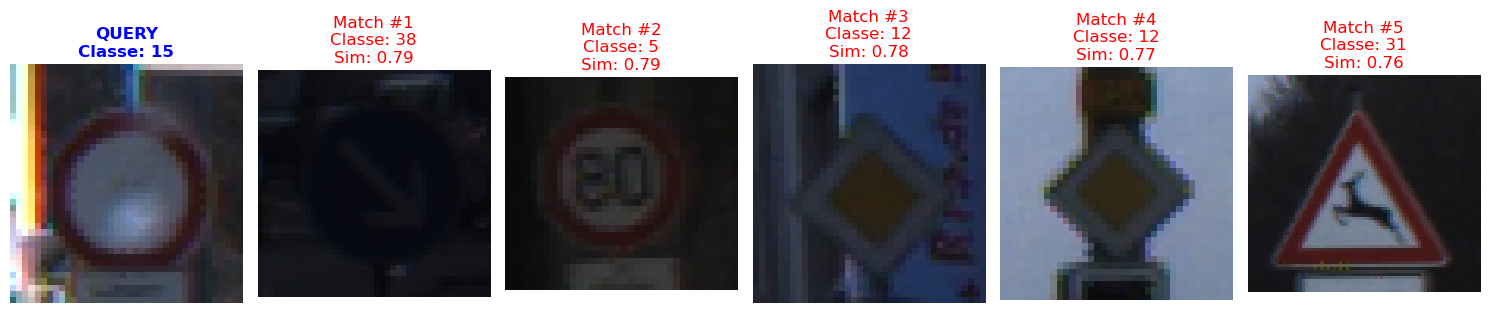

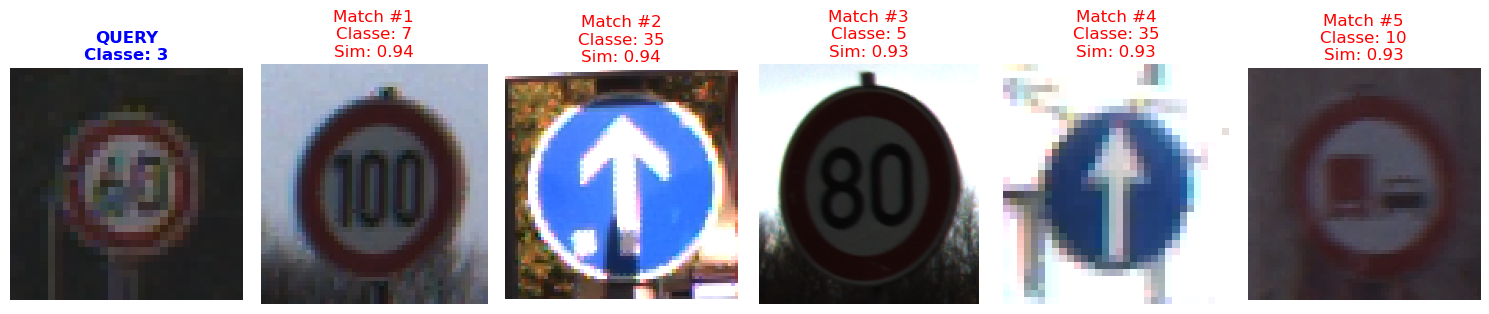

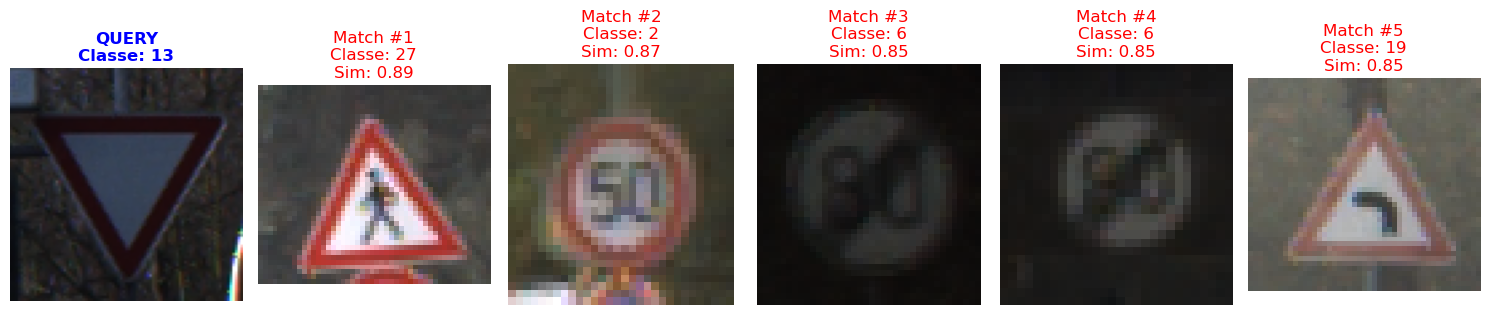

In [62]:
import matplotlib.pyplot as plt
import random

print("Caricamento immagini grezze per la visualizzazione...")
# Carichiamo i dataset originali SENZA normalizzazione solo per vederli bene
ds_vis_train = GTSRB('data/', split='train', download=True)
ds_vis_test  = GTSRB('data/', split='test',  download=True)

def visualize_retrieval(query_index, sim_matrix, k=5):
    """
    Mostra l'immagine Query e le Top-K immagini recuperate dalla Gallery.
    """
    # 1. Recupera l'immagine Query originale
    query_img, query_label = ds_vis_test[query_index]
    
    # 2. Trova le K immagini più simili nella matrice
    # sim_matrix ha dimensione (12630, 26640). Prendiamo la riga della nostra query.
    query_sims = sim_matrix[query_index] 
    
    # Estraiamo gli indici dei punteggi più alti
    topk_scores, topk_indices = torch.topk(query_sims, k)
    
    # 3. Disegno
    plt.figure(figsize=(15, 3))
    
    # Plotta la Query
    plt.subplot(1, k + 1, 1)
    plt.imshow(query_img)
    plt.title(f"QUERY\nClasse: {query_label}", color='blue', fontweight='bold')
    plt.axis('off')
    
    # Plotta i risultati recuperati
    for i in range(k):
        idx_in_gallery = topk_indices[i].item()
        score = topk_scores[i].item()
        
        # Recupera immagine e classe dalla gallery
        retrieved_img, retrieved_label = ds_vis_train[idx_in_gallery]
        
        plt.subplot(1, k + 1, i + 2)
        plt.imshow(retrieved_img)
        
        # Titolo verde se indovina la classe, rosso se sbaglia
        color = 'green' if retrieved_label == query_label else 'red'
        plt.title(f"Match #{i+1}\nClasse: {retrieved_label}\nSim: {score:.2f}", color=color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Testiamo con 3 cartelli casuali
print("\nGenerazione delle visualizzazioni...")
for _ in range(3):
    random_query_idx = random.randint(0, len(ds_vis_test) - 1)
    # Usiamo la cos_matrix calcolata nello step precedente
    visualize_retrieval(random_query_idx, cos_matrix, k=5)

Nearest-Mean Classifier (NMC)

In [63]:
# Trasformiamo il sistema di retrieval in un classificatore vero e proprio.
# Invece di usare la discesa del gradiente, l'addestramento consiste semplicemente nel calcolare il vettore medio (Centroide) per ognuna delle 43 classi. 
# Durante l'inferenza, misuriamo la Cosine Similarity tra ogni immagine di test e i 43 centroidi, assegnando l'immagine alla classe del centroide più simile.

from sklearn.metrics import classification_report

print("--- ADDESTRAMENTO NMC (Zero-Gradient) ---")
# 1. TRAINING: Calcolo dei centroidi (Vettori medi per ogni classe)
num_classes = 43
# Creiamo una matrice vuota (43 classi x 512 dimensioni)
mean_features = torch.zeros(num_classes, gallery_feats.shape[1])

for class_id in range(num_classes):
    # Troviamo tutte le immagini della gallery che appartengono a questa classe
    class_mask = (gallery_labels == class_id)
    class_features = gallery_feats[class_mask]
    
    # Calcoliamo la media lungo la dimensione 0 (le immagini)
    mean_features[class_id] = class_features.mean(dim=0)

print(f"✓ Calcolati {num_classes} centroidi di dimensione {mean_features.shape[1]}")

print("\n--- INFERENZA NMC ---")
# 2. INFERENCE: Calcoliamo la similarità tra le Query e i 43 Centroidi
# Normalizziamo query e centroidi per usare la Cosine Similarity
mean_features_norm = F.normalize(mean_features, p=2, dim=1)
query_feats_norm = F.normalize(query_feats, p=2, dim=1)

# similarity matrix: (12630, 512) @ (512, 43) -> (12630, 43)
# Otteniamo i punteggi di similarità per le 43 classi per ogni singola query
distances = torch.matmul(query_feats_norm, mean_features_norm.T)

# Trova la mean più vicina (argmax sui 43 punteggi)
predicted_classes = distances.argmax(dim=1)

# 3. VALUTAZIONE
correct_preds = (predicted_classes == query_labels).sum().item()
total_preds = query_labels.size(0)
nmc_accuracy = correct_preds / total_preds

print(f"\n🎯 Accuratezza Globale NMC: {nmc_accuracy:.4f} ({nmc_accuracy*100:.2f}%)")

print("\n📊 Classification Report Dettagliato:")
print(classification_report(query_labels.numpy(), predicted_classes.numpy()))

--- ADDESTRAMENTO NMC (Zero-Gradient) ---
✓ Calcolati 43 centroidi di dimensione 512

--- INFERENZA NMC ---

🎯 Accuratezza Globale NMC: 0.3870 (38.70%)

📊 Classification Report Dettagliato:
              precision    recall  f1-score   support

           0       0.05      0.35      0.09        60
           1       0.27      0.32      0.29       720
           2       0.30      0.21      0.25       750
           3       0.19      0.15      0.17       450
           4       0.34      0.29      0.31       660
           5       0.36      0.19      0.25       630
           6       0.51      0.87      0.65       150
           7       0.29      0.22      0.25       450
           8       0.18      0.24      0.20       450
           9       0.45      0.26      0.33       480
          10       0.55      0.60      0.57       660
          11       0.32      0.14      0.19       420
          12       0.89      0.90      0.89       690
          13       0.89      0.90      0.90       720

Valutazione di Backbone Avanzati: ResNet-50

In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.models import get_model
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import average_precision_score, classification_report
import numpy as np

# ==========================================
# 1. FUNZIONE mAP (Retrieval)
# ==========================================
def evaluate_map(sim_matrix, query_labels, gallery_labels):
    print("\n--- RISULTATI RETRIEVAL (mAP) ---")
    sim_matrix_np = sim_matrix.numpy()
    query_labels_np = query_labels.numpy()
    gallery_labels_np = gallery_labels.numpy()
    
    aps = [] 
    for i in tqdm(range(len(query_labels_np)), desc="Calcolo AP per query"):
        y_true = (gallery_labels_np == query_labels_np[i]).astype(int)
        y_scores = sim_matrix_np[i]
        aps.append(average_precision_score(y_true, y_scores))
        
    mAP = np.mean(aps)
    print(f"🎯 mAP Finale: {mAP:.4f} ({mAP*100:.2f}%)")
    return mAP

# ==========================================
# 2. PIPELINE PRINCIPALE (Estrazione + Valutazione)
# ==========================================
def run_zero_shot_pipeline(model_name, dataloader_train, dataloader_test, device):
    print(f"\n{'='*60}")
    print(f"🚀 INIZIO PIPELINE ZERO-SHOT: {model_name.upper()}")
    print(f"{'='*60}")
    
    # --- A. CARICAMENTO MODELLO ---
    model = get_model(model_name, weights='DEFAULT')
    model.fc = nn.Identity()
    model = model.to(device)
    model.eval()
    
    # --- B. ESTRAZIONE FEATURE ---
    def extract(dataloader, desc):
        feats, labels = [], []
        with torch.no_grad():
            for img, lbl in tqdm(dataloader, desc=desc):
                # Resize per prestazioni ottimali su ResNet e passaggio su GPU
                img_resized = TF.resize(img, [224, 224], antialias=True).to(device)
                
                # Inferenza e passaggio su CPU per salvare VRAM
                batch_feats = model(img_resized).cpu()
                feats.append(batch_feats)
                labels.append(lbl)
                
                # Pulizia VRAM
                del img_resized, batch_feats
                torch.cuda.empty_cache()
                
        return torch.cat(feats, 0), torch.cat(labels, 0)
    
    print("\n--- ESTRAZIONE FEATURE ---")
    gallery_feats, gallery_labels = extract(dataloader_train, "   Gallery (Train)")
    query_feats, query_labels = extract(dataloader_test, "   Query (Test)")
    
    # Normalizzazione per Cosine Similarity
    gallery_feats_norm = F.normalize(gallery_feats, p=2, dim=1)
    query_feats_norm = F.normalize(query_feats, p=2, dim=1)

    # --- C. FASE RETRIEVAL (mAP) ---
    print("\n--- MATRICE DI SIMILARITÀ (Query vs Gallery) ---")
    cos_matrix_retrieval = torch.matmul(query_feats_norm, gallery_feats_norm.T)
    
    map_score = evaluate_map(cos_matrix_retrieval, query_labels, gallery_labels)
    del cos_matrix_retrieval # Eliminiamo la matrice gigante per liberare RAM

    # --- D. FASE CLASSIFICAZIONE (Il tuo codice NMC) ---
    print("\n--- ADDESTRAMENTO NMC (Zero-Gradient) ---")
    num_classes = 43
    mean_features = torch.zeros(num_classes, gallery_feats.shape[1])

    for class_id in range(num_classes):
        class_mask = (gallery_labels == class_id)
        class_features = gallery_feats[class_mask]
        mean_features[class_id] = class_features.mean(dim=0)

    print(f"✓ Calcolati {num_classes} centroidi di dimensione {mean_features.shape[1]}")

    print("\n--- INFERENZA NMC ---")
    mean_features_norm = F.normalize(mean_features, p=2, dim=1)
    
    # Cosine Similarity: Query vs 43 Centroidi
    distances = torch.matmul(query_feats_norm, mean_features_norm.T)
    predicted_classes = distances.argmax(dim=1)

    correct_preds = (predicted_classes == query_labels).sum().item()
    total_preds = query_labels.size(0)
    nmc_accuracy = correct_preds / total_preds

    print(f"🎯 Accuratezza Globale NMC: {nmc_accuracy:.4f} ({nmc_accuracy*100:.2f}%)")

    print("\n📊 Classification Report Dettagliato:")
    # Tutto è già su CPU, possiamo passare direttamente a NumPy
    print(classification_report(query_labels.numpy(), predicted_classes.numpy(), zero_division=0))
    
    # Pulizia finale
    del model, gallery_feats, query_feats, distances
    torch.cuda.empty_cache() 
    
    return map_score, nmc_accuracy

# ==========================================
# 3. ESECUZIONE CON PROTEZIONE MEMORIA
# ==========================================
torch.cuda.empty_cache()

print("🔧 Preparazione DataLoader sicuri (Batch Size: 16)...")
# Usa i dataset che hai già caricato in memoria
dl_train_safe = DataLoader(dl_train.dataset, batch_size=16, shuffle=False, num_workers=2)
dl_test_safe  = DataLoader(dl_test.dataset, batch_size=16, shuffle=False, num_workers=2)

# Lancia la pipeline
map_res50, acc_res50 = run_zero_shot_pipeline('resnet50', dl_train_safe, dl_test_safe, device)

🔧 Preparazione DataLoader sicuri (Batch Size: 16)...

🚀 INIZIO PIPELINE ZERO-SHOT: RESNET50

--- ESTRAZIONE FEATURE ---


   Query (Test): 100%|██████████| 790/790 [01:34<00:00,  8.39it/s]



--- MATRICE DI SIMILARITÀ (Query vs Gallery) ---

--- RISULTATI RETRIEVAL (mAP) ---


Calcolo AP per query: 100%|██████████| 12630/12630 [00:47<00:00, 268.69it/s]


🎯 mAP Finale: 0.2187 (21.87%)

--- ADDESTRAMENTO NMC (Zero-Gradient) ---
✓ Calcolati 43 centroidi di dimensione 2048

--- INFERENZA NMC ---
🎯 Accuratezza Globale NMC: 0.4585 (45.85%)

📊 Classification Report Dettagliato:
              precision    recall  f1-score   support

           0       0.01      0.05      0.01        60
           1       0.32      0.36      0.34       720
           2       0.40      0.17      0.24       750
           3       0.27      0.23      0.25       450
           4       0.47      0.34      0.40       660
           5       0.29      0.24      0.26       630
           6       0.69      0.99      0.81       150
           7       0.62      0.53      0.57       450
           8       0.18      0.22      0.20       450
           9       0.56      0.53      0.55       480
          10       0.52      0.51      0.51       660
          11       0.79      0.14      0.24       420
          12       1.00      0.92      0.96       690
          13       0.9

## Nota finale

Il notebook mantiene gli output storici senza duplicare la prima parte di EDA. Per una consegna pulita, i notebook modulari in `notebooks/` restano la versione principale; questo file serve come archivio ordinato degli esperimenti di prova e dei risultati che non devono andare persi.